# revT2V: compare reverse-time methods

All methods run on **one shared U-Net** (`revt2v.infer.MethodBank`) from the **same initial noise `z`**:

| Column | What it is |
|---|---|
| `teacher` | frozen ModelScope teacher, forward time, from `z` |
| `matched_target` | `reverse(teacher(latents = flip(z)))`, the per-sample reference a reverse generator started from `z` should reproduce |
| `attn_rotation` | trained self-rotation + LoRA (up-block temporal attn1) |
| `conv_oracle` | teacher with every temporal Conv3d kernel flipped in time; no training |
| `conv_student` | LoRA on temporal Conv3d (only if its checkpoint exists) |

**Caveat:** `conv_oracle` is an exact time-mirror of the teacher (`unet_flipped(z) == flip(unet(flip(z)))`), so it is equivalent to reversing the teacher's output. It's a **reference / upper bound**, not a learned method.

Scoring is done by `scripts/evaluate.py`, every method vs `matched_target`:
- **FVD**: I3D features vs the matched-target set (lower = better). Noisy with few videos, so directional only.
- **CLIP score**: 100 × CLIP cosine(frame, prompt), averaged over frames (higher = better).
- **VBench dynamic degree**: binary per video; per method, the fraction of videos that move.
- **Flow cosine** (RAFT, Farneback fallback, at 256×256): direction agreement of the signed flow vs the target at the same frame pair (+1 = same motion direction, -1 = opposite).

`matched_target` is the reference, so its FVD and flow cosine are NaN. The summary averages each per-video metric per method.

## 1. Setup

In [ ]:
# Change this to your GitHub username
GITHUB_USER = "silentlooop"

!git clone -q https://github.com/{GITHUB_USER}/revT2V.git /content/revT2V 2>/dev/null || git -C /content/revT2V pull -q
%cd /content/revT2V
!pip install -q -e ".[eval]"
# VBench pins transformers==4.33.2 and numpy<2, which would break diffusers, so
# install it without deps plus easydict, the only extra its dynamic_degree needs.
# decord has no wheels for Python 3.13; scripts/evaluate.py swaps in an imageio stand-in.
!pip install -q --no-deps vbench
!pip install -q easydict
!pip uninstall torchao
# no %autoreload: it breaks on Colab's Python 3.13 (removed `imp` module).
# After a git pull, restart the kernel and re-run from the top.

/content/revT2V
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for revt2v (pyproject.toml) ... done


In [ ]:
import os
import torch

HF_TOKEN = ""  # paste your Hugging Face token here
os.environ["HF_TOKEN"] = HF_TOKEN
print("CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

CUDA: True | Tesla T4


In [32]:
HF_REPO = "silentlooop/revt2v-ckpt"

PROMPT_SETS = {
    # fluids / gravity / walking: the original comparison set
    "physics": [
        "an apple falling from a tree branch onto the grass, static camera",
        "orange juice being poured into a glass, close-up",
    ]
}
PROMPT_SET = "physics"  # "physics" | "irreversible"
PROMPTS = PROMPT_SETS[PROMPT_SET]
OUT_DIR = f"/content/compare_results/{PROMPT_SET}"  # one folder per set, so runs don't overwrite
VIDEOS_DIR = f"{OUT_DIR}/videos"  # <method>/<name>.mp4 + prompts.json, the layout evaluate.py scores
SEEDS = [0, 1]
GEN = dict(negative_prompt="watermark, text", num_inference_steps=25, guidance_scale=9.0,
           num_frames=16, height=256, width=256)
SHEET_FRAMES = [0, 5, 10, 15]
FPS = 8
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load the teacher once, then the trained adapters

In [33]:
from revt2v.infer import MethodBank

bank = MethodBank(hf_repo_id=HF_REPO)
bank.pipeline.set_progress_bar_config(disable=True)

# attn_rotation: tries attn_rotation/latest.pt, then the original root latest.pt.
for method in ["attn_rotation", "conv_student", "conv_lora", "attn_lora"]:
    try:
        print(method, "loaded" if bank.load_adapter(method) else "-> no checkpoint, skipped")
    except Exception as exc:  # e.g. root checkpoint belongs to another method
        print(method, "-> skipped:", exc)

print("available methods:", bank.methods)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


attn_rotation -> skipped: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported
conv_student -> no checkpoint, skipped
available methods: ['teacher', 'conv_oracle']


In [34]:
def initial_noise(seed):
    g = torch.Generator(device="cuda").manual_seed(seed)
    return torch.randn((1, 4, GEN["num_frames"], GEN["height"] // 8, GEN["width"] // 8),
                       generator=g, device="cuda", dtype=bank.pipeline.unet.dtype)

def to_np(video):
    """(F, H, W, C) float tensor in [0, 1] -> float32 numpy."""
    return video.float().clamp(0, 1).cpu().numpy()

## 3. Exactness checks
(a) U-Net level: `unet_flipped(z, t, emb)` vs `flip(unet(flip(z), t, emb))`

In [35]:
from contextlib import nullcontext
from revt2v.methods.conv_mirror import find_temporal_convs, flip_temporal_convs, set_flip_state
from revt2v.teacher import encode_prompt

unet = bank.pipeline.unet
print(len(find_temporal_convs(unet)), "temporal Conv3d layers")

z = initial_noise(0)
emb, _ = encode_prompt(bank.pipeline, PROMPTS[0])
emb = emb.to(unet.dtype)
t = torch.tensor([500], device="cuda")

adapters_off = bank.student.disable_adapter() if bank.student is not None else nullcontext()
try:
    with torch.no_grad(), adapters_off:
        mirrored = unet(z.flip(2), t, encoder_hidden_states=emb, return_dict=False)[0].flip(2)
        flip_temporal_convs(unet)
        flipped = unet(z, t, encoder_hidden_states=emb, return_dict=False)[0]
finally:
    set_flip_state(unet, ())

print(f"max |unet_flipped(z) - flip(unet(flip(z)))| = {(flipped.float() - mirrored.float()).abs().max().item():.3e}")

88 temporal Conv3d layers
max |unet_flipped(z) - flip(unet(flip(z)))| = 3.906e-03


(b) Video level: `conv_oracle(latents=z)` vs `matched_target(prompt, z)`

In [36]:
z = initial_noise(0)
oracle = to_np(bank.generate(PROMPTS[0], "conv_oracle", latents=z, **GEN)["video"])
target = to_np(bank.matched_target(PROMPTS[0], z, **GEN)["video"])
print(f"mean pixel diff (0-1 scale): {abs(oracle - target).mean():.4f}")

mean pixel diff (0-1 scale): 0.0026


## 4. Load `scripts/evaluate.py`

In [37]:
import importlib.util
import numpy as np

# scripts/ isn't a package (and `evaluate` would clash with Hugging Face's
# `evaluate` library), so load the file directly.
spec = importlib.util.spec_from_file_location("revt2v_evaluate", "scripts/evaluate.py")
ev = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ev)

## 5. Generate every method from the same noise

In [38]:
from diffusers.utils import export_to_video
from IPython.display import Video, display

COLUMNS = [m for m in ["teacher", "matched_target", "attn_rotation", "conv_oracle", "conv_student",
           "conv_lora", "attn_lora"]
           if m == "matched_target" or m in bank.methods]

# Every method + matched_target from the same noise per (prompt, seed); names are p<idx>_s<seed>.
videos, names = ev.generate_videos(bank, PROMPTS, SEEDS, [m for m in COLUMNS if m != "matched_target"], GEN)
ev.save_video_set(videos, names, VIDEOS_DIR, fps=FPS)

os.makedirs(f"{OUT_DIR}/side_by_side", exist_ok=True)
for name, prompt in names.items():
    side_by_side = np.clip(np.concatenate([videos[m][name] for m in COLUMNS], axis=2), 0, 1)
    # export_to_video expects float frames in [0, 1], not uint8
    path = export_to_video(list(side_by_side), f"{OUT_DIR}/side_by_side/{name}.mp4", fps=FPS)
    print(f"{name}: {prompt}\n    " + " | ".join(COLUMNS))
    display(Video(path, embed=True, width=256 * len(COLUMNS)))

p0_s0: an apple falling from a tree branch onto the grass, static camera
    teacher | matched_target | conv_oracle


p0_s1: an apple falling from a tree branch onto the grass, static camera
    teacher | matched_target | conv_oracle


p1_s0: orange juice being poured into a glass, close-up
    teacher | matched_target | conv_oracle


p1_s1: orange juice being poured into a glass, close-up
    teacher | matched_target | conv_oracle


## 6. Scores from `scripts/evaluate.py` (vs matched target)

In [39]:
import pandas as pd

# The first run downloads CLIP ViT-L/14, I3D and the VBench models (a few GB).
# Writes metrics.csv, summary.csv and summary.json to OUT_DIR.
result = ev.score_videos_dir(VIDEOS_DIR, output_dir=OUT_DIR)

summary = pd.DataFrame(result["summary"]).set_index("method")
display(summary.round(3))
display(pd.DataFrame(result["rows"]).round(3))

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/raft_large_C_T_SKHT_V2-ff5fadd5.pth" to /root/.cache/torch/hub/checkpoints/raft_large_C_T_SKHT_V2-ff5fadd5.pth
Evaluation meta data saved to /content/compare_results/physics/vbench/conv_oracle__dynamic_degree_full_info.json
cur_full_info_path: /content/compare_results/physics/vbench/conv_oracle__dynamic_degree_full_info.json



/usr/local/lib/python3.13/dist-packages/vbench/third_party/RAFT/core/raft.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/usr/local/lib/python3.13/dist-packages/vbench/third_party/RAFT/core/raft.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/usr/local/lib/python3.13/dist-packages/vbench/third_party/RAFT/core/raft.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):










100%|██████████| 10/10 [00:16<00:00,  1.65s/it]


Evaluation results saved to /content/compare_results/physics/vbench/conv_oracle__dynamic_degree_eval_results.json
Evaluation meta data saved to /content/compare_results/physics/vbench/matched_target__dynamic_degree_full_info.json
cur_full_info_path: /content/compare_results/physics/vbench/matched_target__dynamic_degree_full_info.json













100%|██████████| 10/10 [00:16<00:00,  1.66s/it]


Evaluation results saved to /content/compare_results/physics/vbench/matched_target__dynamic_degree_eval_results.json
Evaluation meta data saved to /content/compare_results/physics/vbench/teacher__dynamic_degree_full_info.json
cur_full_info_path: /content/compare_results/physics/vbench/teacher__dynamic_degree_full_info.json













100%|██████████| 10/10 [00:16<00:00,  1.66s/it]


Evaluation results saved to /content/compare_results/physics/vbench/teacher__dynamic_degree_eval_results.json


,videos,fvd,clip_score,flow_cosine,vbench_dynamic_degree
method,,,,,
conv_oracle,10,141.896,32.675,0.879,0.6
matched_target,10,NaN,32.658,NaN,0.6
teacher,10,1524.228,32.685,0.411,0.7


,method,video,prompt,clip_score,flow_cosine,vbench_dynamic_degree
0,conv_oracle,p0_s0,an apple falling from a tree branch onto the g...,31.229,0.648,0.0
1,conv_oracle,p0_s1,an apple falling from a tree branch onto the g...,34.602,0.959,0.0
2,conv_oracle,p1_s0,"orange juice being poured into a glass, close-up",31.646,0.865,1.0
3,conv_oracle,p1_s1,"orange juice being poured into a glass, close-up",33.225,0.932,0.0
4,conv_oracle,p2_s0,,NaN,0.893,1.0
5,conv_oracle,p2_s1,,NaN,0.803,1.0
6,conv_oracle,p3_s0,,NaN,0.881,1.0
7,conv_oracle,p3_s1,,NaN,0.950,1.0
8,conv_oracle,p4_s0,,NaN,0.885,0.0
9,conv_oracle,p4_s1,,NaN,0.975,1.0


## 7. Frame sheets (rows = methods, columns = frames)

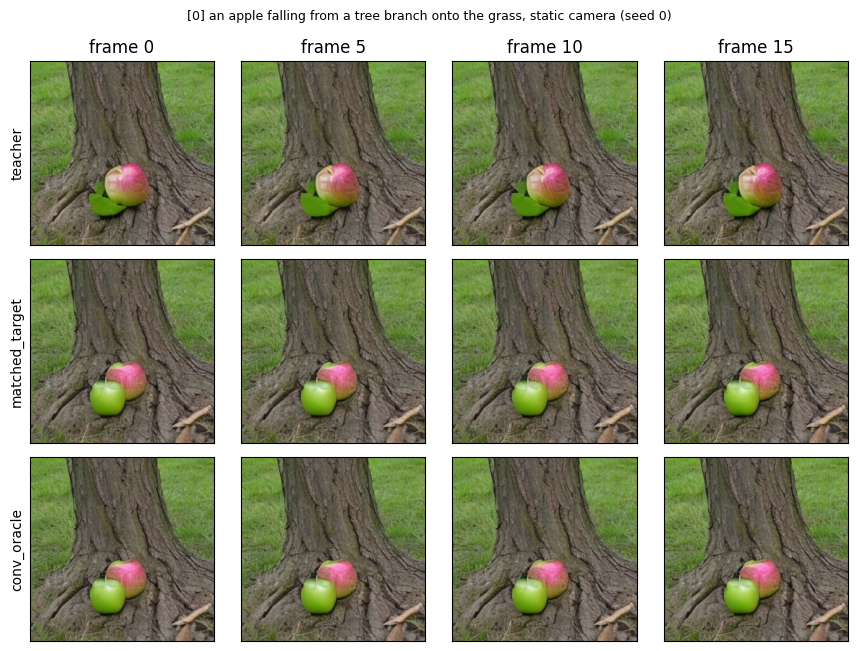

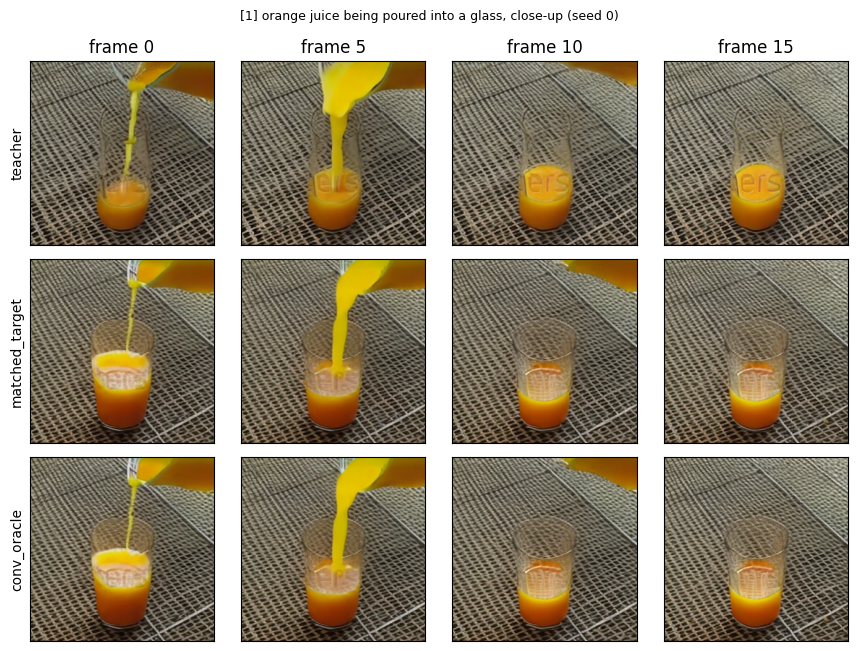

In [40]:
import matplotlib.pyplot as plt

for p_idx, prompt in enumerate(PROMPTS):
    name = f"p{p_idx}_s{SEEDS[0]}"
    fig, axes = plt.subplots(len(COLUMNS), len(SHEET_FRAMES),
                             figsize=(2.2 * len(SHEET_FRAMES), 2.2 * len(COLUMNS)), squeeze=False)
    for r, method in enumerate(COLUMNS):
        for c, f in enumerate(SHEET_FRAMES):
            ax = axes[r][c]
            ax.imshow(np.clip(videos[method][name][f], 0, 1))
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0: ax.set_title(f"frame {f}")
            if c == 0: ax.set_ylabel(method)
    fig.suptitle(f"[{p_idx}] {prompt} (seed {SEEDS[0]})", fontsize=9)
    fig.tight_layout()
    fig.savefig(f"{OUT_DIR}/p{p_idx}_frame_sheet.png", dpi=100)
    plt.show()

## 8. Zip and download

In [41]:
import shutil
from google.colab import files

archive = shutil.make_archive(f"/content/compare_results_{PROMPT_SET}", "zip", OUT_DIR)
print(archive)
files.download(archive)

/content/compare_results_physics.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>